Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


<function matplotlib.pyplot.show(close=None, block=None)>

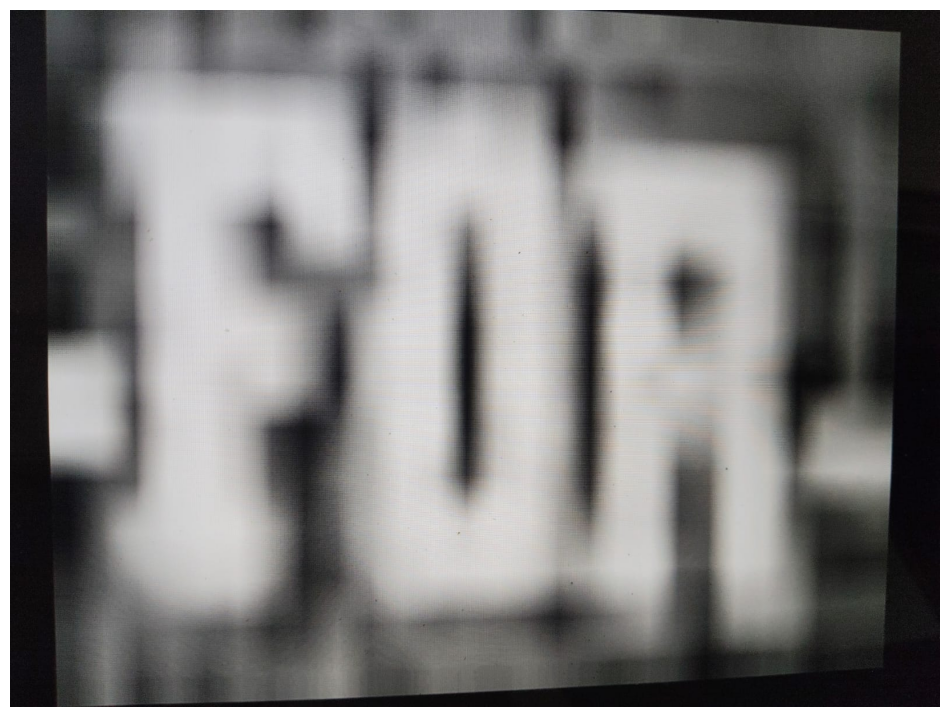

In [2]:
import easyocr
import cv2
import matplotlib.pyplot as plt
import numpy as np




reader_cn = easyocr.Reader(['ch_sim','en'])
reader_hi = easyocr.Reader(['hi','en'])
reader_es = easyocr.Reader(['es','en','fr'])

image_path='test.jpeg'
image= cv2.imread(image_path)
kernel = np.array([[0, -1, 0] , [-1, 5, -1], [0, -1, 0]])
sharpened = cv2.filter2D(image, -1, kernel)

results_cn= reader_cn.readtext(sharpened)
results_hi=reader_hi.readtext(sharpened)
results_es=reader_es.readtext(sharpened)
results= results_cn + results_hi + results_es

for(bbox, text, prob) in results:
    print(f"Detected Text: {text} (Confidence: {prob:.2f})")

    (top_left, top_right, bottom_right, bottom_left)=bbox
    top_left= tuple(map(int, top_left))
    bottom_right= tuple(map(int, bottom_right))
    cv2.rectangle(image, top_left, bottom_right, (0,255,0),2)
    cv2.putText(image, text, top_left, cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,0,255),2)


plt.figure(figsize=(12,12))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show
